# Faz 2: Supervised Model Comparison

Bu notebookta anomaly etiketi bulunan veri seti kullanılarak supervised learning modelleri karşılaştırılmıştır.

Faz 1’de veri analizi, anomaly analizi ve gözetimsiz anomaly detection yöntemleri incelenmiştir.

Bu fazda amaç, anomaly detection problemini supervised classification problemi olarak ele almak ve farklı modellerin performanslarını karşılaştırmaktır.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## Dataset Loading

Bu bölümde anomaly etiketi bulunan temiz veri seti okunmuştur.

In [13]:
df = pd.read_csv("../data/processed/anomaly_dataset_clean.csv")

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Part_of_Day,Part_of_Day_Code,Average_Indoor_Temperature,Average_Indoor_Humidity,Delta_T,Thermal_Comfort_Index,Energy_Lag_1,Energy_Rolling_Mean,Energy_Rolling_Std,is_anomaly
0,2016-01-11 17:50:00,50,40,19.890000,46.026667,19.20,44.500000,19.79,44.933333,18.89,...,Aksam,3,17.048519,50.791852,11.031852,16.358775,60.0,55.000000,5.477226,0
1,2016-01-11 18:00:00,60,50,19.890000,45.766667,19.20,44.500000,19.79,44.900000,18.89,...,Aksam,3,17.040741,50.788148,11.140741,16.353051,50.0,55.000000,5.477226,0
2,2016-01-11 18:10:00,60,50,19.856667,45.560000,19.20,44.500000,19.73,44.900000,18.89,...,Aksam,3,17.018519,50.802963,11.101852,16.337048,60.0,55.000000,5.477226,0
3,2016-01-11 18:20:00,60,40,19.790000,45.597500,19.20,44.433333,19.73,44.790000,18.89,...,Aksam,3,17.018519,50.901944,11.085185,16.338420,60.0,56.666667,5.163978,0
4,2016-01-11 18:30:00,70,40,19.856667,46.090000,19.23,44.400000,19.79,44.863333,18.89,...,Aksam,3,17.039630,51.050741,11.089630,16.355908,60.0,60.000000,6.324555,0


## Feature and Target Selection

Bu bölümde modelin kullanacağı bağımsız değişkenler ve hedef değişken ayrılmıştır.

Hedef değişken `is_anomaly` sütunudur.

In [14]:
features = [
    "Appliances",
    "Hour",
    "DayOfWeek",
    "Is_Weekend",
    "Part_of_Day_Code",
    "Average_Indoor_Temperature",
    "Delta_T",
    "Thermal_Comfort_Index",
    "Energy_Lag_1",
    "Energy_Rolling_Mean",
    "Energy_Rolling_Std"
]

X = df[features]
y = df["is_anomaly"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19730, 11)
y shape: (19730,)


In [15]:
print(df.columns.tolist())

['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'Hour', 'DayOfWeek', 'Is_Weekend', 'Part_of_Day', 'Part_of_Day_Code', 'Average_Indoor_Temperature', 'Average_Indoor_Humidity', 'Delta_T', 'Thermal_Comfort_Index', 'Energy_Lag_1', 'Energy_Rolling_Mean', 'Energy_Rolling_Std', 'is_anomaly']


## Feature Scaling

Bazı supervised learning modelleri ölçek farklılıklarından etkilenebilir.

Bu nedenle feature değerleri StandardScaler ile ölçeklendirilmiştir.

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Train-Test Split

Veri seti eğitim ve test olmak üzere ikiye ayrılmıştır.

Stratify kullanılarak normal ve anomaly sınıflarının dağılımı korunmuştur.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (15784, 11)
Test shape: (3946, 11)


# Logistic Regression

Logistic Regression baseline model olarak kullanılmıştır.

Bu model daha basit bir yapı sunduğu için diğer modellerle karşılaştırmada referans olarak değerlendirilmiştir.

In [18]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print(classification_report(y_test, log_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3879
           1       0.79      1.00      0.88        67

    accuracy                           1.00      3946
   macro avg       0.89      1.00      0.94      3946
weighted avg       1.00      1.00      1.00      3946



# Random Forest

Random Forest modeli dengesiz veri setlerinde güçlü sonuçlar verebildiği ve feature importance sağlayabildiği için kullanılmıştır.

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(classification_report(y_test, rf_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3879
           1       1.00      0.97      0.98        67

    accuracy                           1.00      3946
   macro avg       1.00      0.99      0.99      3946
weighted avg       1.00      1.00      1.00      3946



In [20]:
try:
    from xgboost import XGBClassifier
    xgb_available = True
    print("XGBoost kullanılabilir.")
except ImportError:
    xgb_available = False
    print("XGBoost yüklü değil. Bu bölüm atlanacak.")

XGBoost yüklü değil. Bu bölüm atlanacak.


# XGBoost

XGBoost güçlü bir boosting algoritmasıdır.

Kurulu olması durumunda supervised model karşılaştırmasına dahil edilmiştir.

In [21]:
if xgb_available:
    xgb_model = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    xgb_pred = xgb_model.predict(X_test)

    print(classification_report(y_test, xgb_pred, zero_division=0))

# Model Comparison Table

Bu bölümde supervised modeller precision, recall ve F1-score değerlerine göre karşılaştırılmıştır.

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_results = []

def add_model_result(model_name, y_true, y_pred):
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    })

add_model_result("Logistic Regression", y_test, log_pred)
add_model_result("Random Forest", y_test, rf_pred)

if xgb_available:
    add_model_result("XGBoost", y_test, xgb_pred)

model_results_df = pd.DataFrame(model_results)
model_results_df = model_results_df.sort_values(by="F1 Score", ascending=False)

model_results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.999493,1.000000,0.970149,0.984848
0,Logistic Regression,0.995438,0.788235,1.000000,0.881579


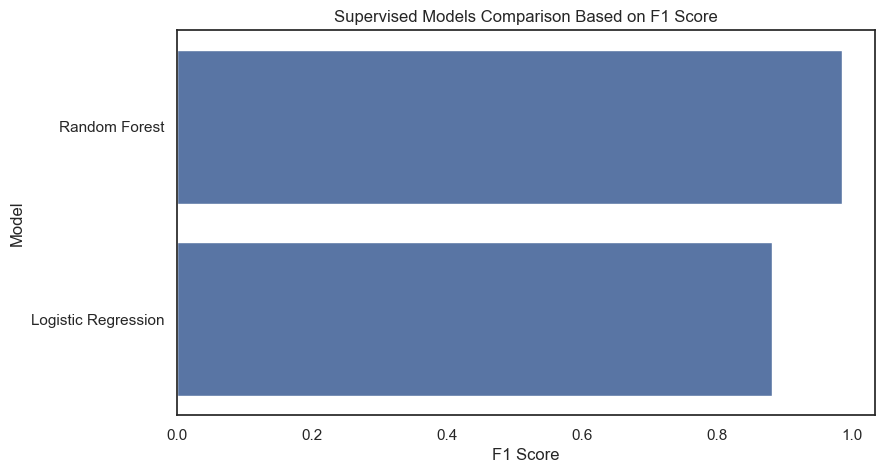

In [23]:
plt.figure(figsize=(9,5))

sns.barplot(
    x="F1 Score",
    y="Model",
    data=model_results_df
)

plt.title("Supervised Models Comparison Based on F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.show()

# Best Model Confusion Matrix

Bu bölümde en yüksek F1-score değerine sahip modelin confusion matrix sonucu gösterilmiştir.

Best Model: Random Forest


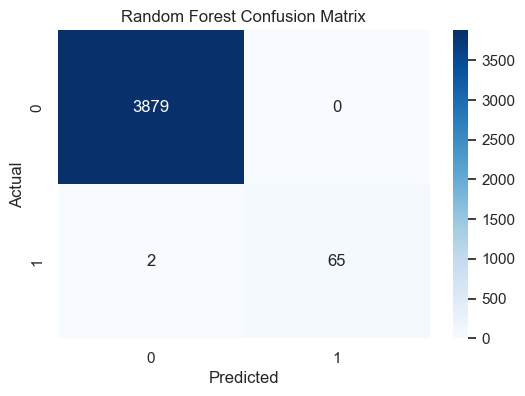

In [24]:
best_model_name = model_results_df.iloc[0]["Model"]

if best_model_name == "Logistic Regression":
    best_pred = log_pred
elif best_model_name == "Random Forest":
    best_pred = rf_pred
else:
    best_pred = xgb_pred

print("Best Model:", best_model_name)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"{best_model_name} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 5-Fold Stratified Cross Validation

Bu bölümde modeller 5 farklı veri bölünmesi üzerinde test edilmiştir.

Bu yöntem modelin tek bir train-test ayrımına bağlı kalmadan daha güvenilir değerlendirilmesini sağlar.

In [25]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_scaled,
        y,
        cv=cv,
        scoring=["precision", "recall", "f1"],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(by="F1 Mean", ascending=False)

cv_results_df

,Model,Precision Mean,Recall Mean,F1 Mean,F1 Std
1,Random Forest,1.000000,0.913608,0.95411,0.028259
0,Logistic Regression,0.812092,0.994030,0.89344,0.014367


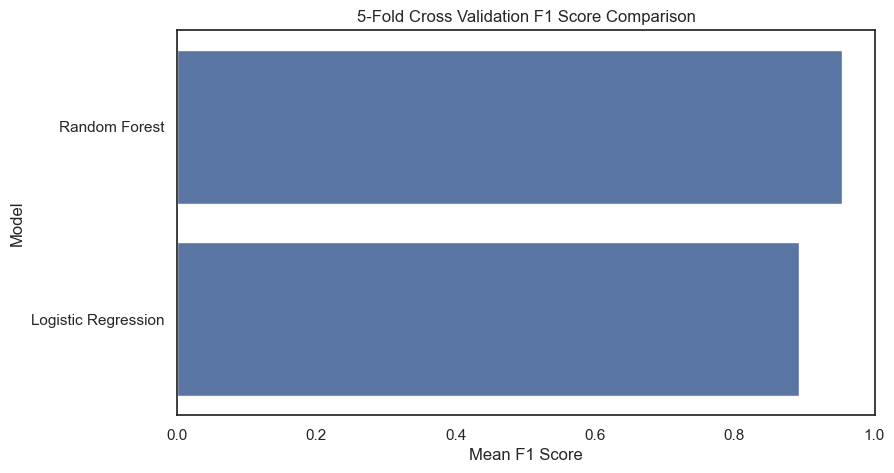

In [26]:
plt.figure(figsize=(9,5))

sns.barplot(
    x="F1 Mean",
    y="Model",
    data=cv_results_df
)

plt.title("5-Fold Cross Validation F1 Score Comparison")
plt.xlabel("Mean F1 Score")
plt.ylabel("Model")

plt.show()

# Feature Importance

Bu bölümde Random Forest modelinin karar verirken hangi özelliklere daha fazla önem verdiği incelenmiştir.

In [27]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,Appliances,0.746122
6,Delta_T,0.065064
2,DayOfWeek,0.037968
7,Thermal_Comfort_Index,0.036358
5,Average_Indoor_Temperature,0.033781
10,Energy_Rolling_Std,0.019790
9,Energy_Rolling_Mean,0.018700
3,Is_Weekend,0.016723
1,Hour,0.011568
8,Energy_Lag_1,0.010895


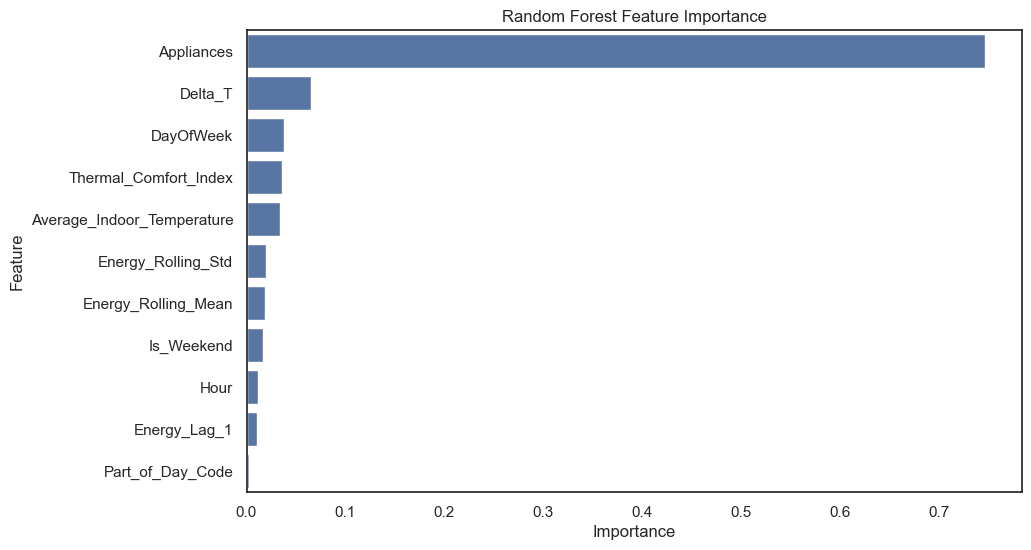

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Final Conclusion

Bu fazda anomaly detection problemi supervised classification problemi olarak ele alınmıştır.

Logistic Regression, Random Forest ve mümkünse XGBoost modelleri karşılaştırılmıştır.

Model değerlendirmesinde accuracy yerine özellikle precision, recall ve F1-score metrikleri dikkate alınmıştır.

Çünkü anomaly detection problemlerinde veri genellikle dengesizdir ve sadece accuracy değeri model başarısını doğru şekilde yansıtmayabilir.

Cross validation sonuçları modelin farklı veri bölünmelerindeki performansını göstermiştir.

Bu nedenle en başarılı model seçilirken hem test seti performansı hem de cross validation sonuçları birlikte değerlendirilmiştir.

Ek olarak anomaly etiketi kullanılarak supervised classification modelleri de denenmiştir.
Ancak proje temel olarak unsupervised anomaly detection yaklaşımına odaklanmaktadır.